# 👩‍💻 Visualizing Customer Segmentation Data

## 📋 Overview
In this lab, you’ll explore the **Mall Customer Segmentation Dataset** to develop your intuition about **grouping customers without labels**. You'll work through a real-world exploratory process before applying clustering algorithms like **K-Means** later.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

 - Load and inspect an unlabeled customer dataset
 
 - Visualize distributions and relationships among features
 
 - Identify outliers and consider their impact
 
 - Document visual insights that guide clustering strategies

## Task 1: Load and Explore the Dataset
**Context:** Start by loading the customer dataset and exploring its structure.

**Steps:**

1. Load the dataset using Pandas `(pd.read_csv()`.

2. Use `.head()`, `.info()`, and `.describe()` to understand:

   - Number of samples and features

   - Data types (numerical vs categorical)

   - Feature names like `Age`, `Annual Income (k$)`, `Spending Score (1-100)`

**Prompting Questions:**

- Are the features appropriate for numerical analysis?
- Any categorical data that won't be used immediately?


In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv('Mall_Customers.csv')

# Quick look at the data
# <your code here>
print(data.shape)
data.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


In [5]:
print(data['Gender'].value_counts(dropna=False))
print(data['Gender'].value_counts(dropna=False, normalize=True))

Female    112
Male       88
Name: Gender, dtype: int64
Female    0.56
Male      0.44
Name: Gender, dtype: float64


💡 **Tip:** Always check data types to avoid issues later in visualization or modeling.

⚙️ **Test Your Work:**

- DataFrame prints correctly
- No unexpected data types for numerical features

## Task 2: Preprocess the Data
**Context:** Clean data is crucial for meaningful visualizations.

**Steps:**

1. Check for missing values using `.isnull().sum()`.
2. Handle missing data if found (drop or impute).
3. Ensure numeric fields (`Age, Annual Income`, `Spending Score`) are properly formatted.
4.(Optional) Clip or handle extreme outliers if obvious.

**Prompting Questions:**

- Any missing data that needs addressing?
- Are all numeric columns truly numeric (no strange formatting)?


💡 **Tip:** Use `pd.to_numeric()` if conversion is needed.

In [6]:
# Preprocess data: check for missing values and handle outliers

data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
# Check data types
data.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

⚙️ **Test Your Work:**

- Clean dataset with no missing values
- Numerical features ready for visualization

## Task 3: Visualize Basic Distributions
**Context:** Visualize individual features to understand their spread and shape.

**Steps:**

1. Plot histograms for `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`.
2. Optionally, create density plots (`sns.kdeplot()`) for smoother distribution curves.


**Prompting Questions:**

- Which features are skewed?
- Are there multi-modal distributions (more than one peak)?


💡 **Tip:** Look at both histogram shape and range when analyzing feature spread.

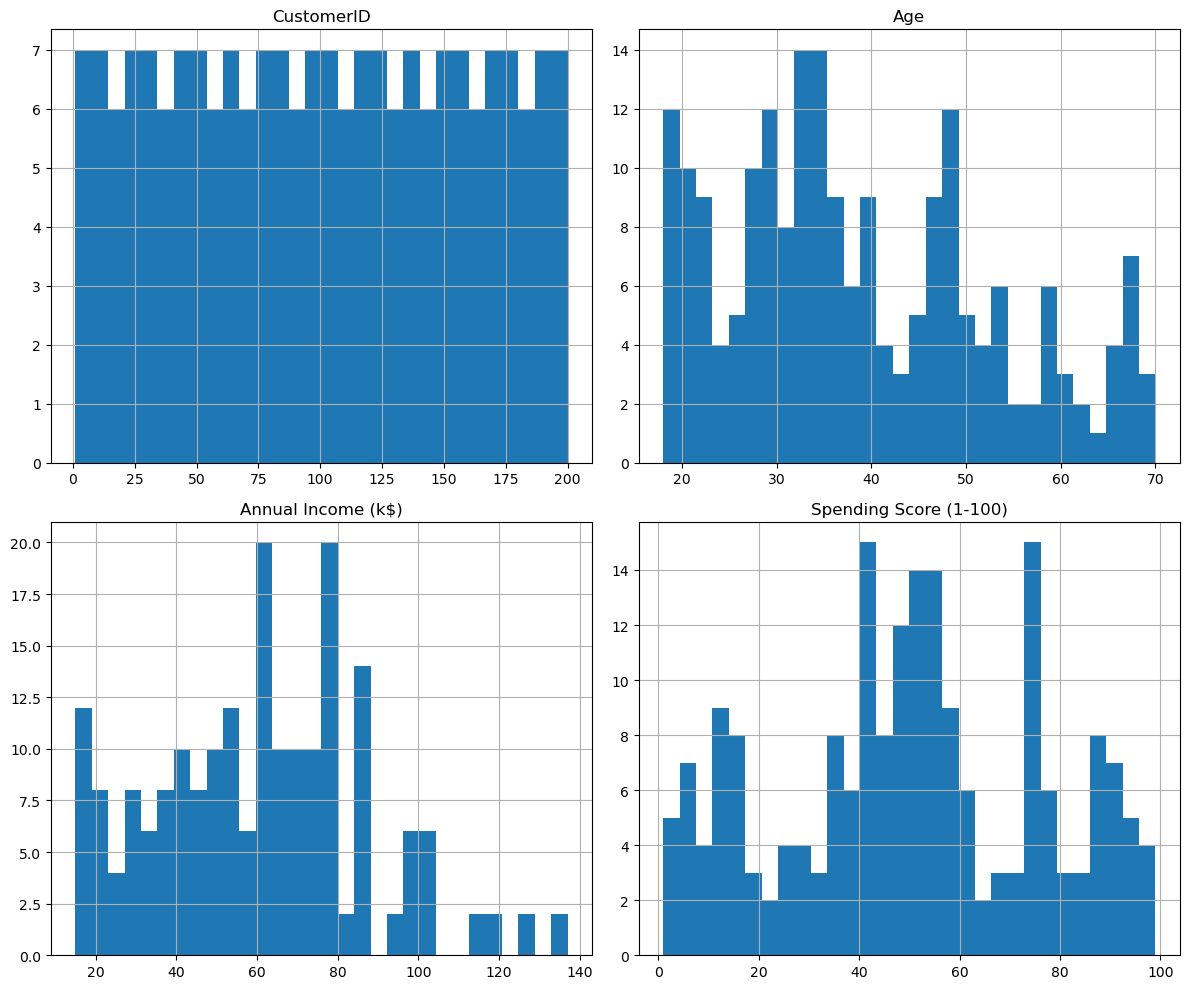

In [8]:
# Visualize distributions using histograms and density plots

# Optional: Density plot for Age sns.kdeplot(data['Age'], fill=True) # Added KDE plot example plt.title('Age Distribution (KDE)') # Added (KDE) for clarity plt.xlabel('Age') plt.ylabel('Density') plt.show()

data.hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()

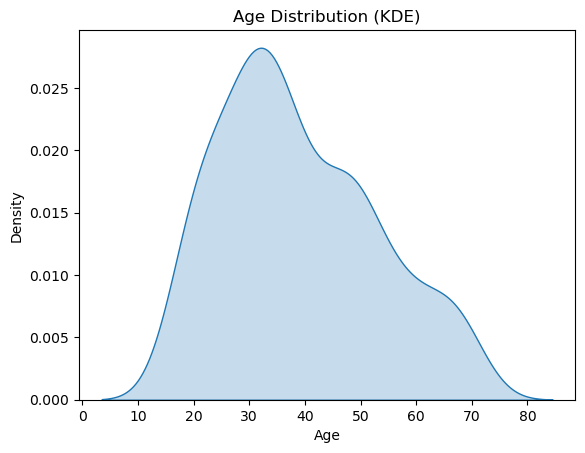

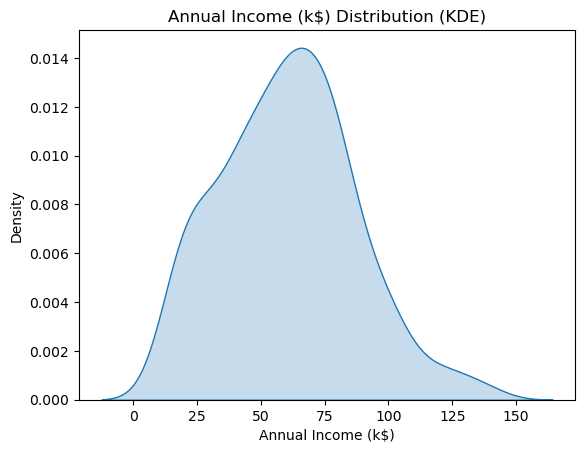

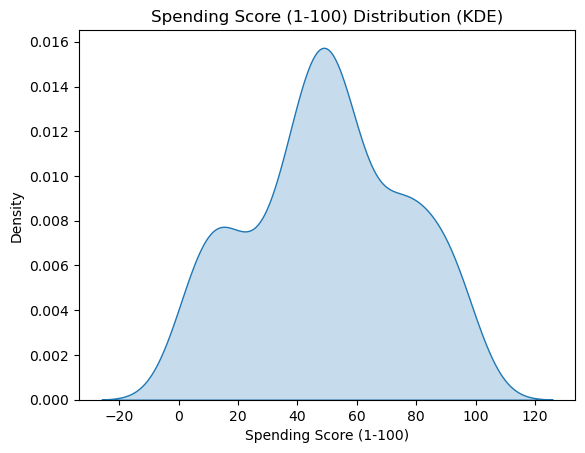

In [9]:
sns.kdeplot(data['Age'], fill=True)
plt.title('Age Distribution (KDE)')
plt.xlabel('Age') 
plt.ylabel('Density') 
plt.show()

sns.kdeplot(data['Annual Income (k$)'], fill=True)
plt.title('Annual Income (k$) Distribution (KDE)')
plt.xlabel('Annual Income (k$)') 
plt.ylabel('Density') 
plt.show()

sns.kdeplot(data['Spending Score (1-100)'], fill=True)
plt.title('Spending Score (1-100) Distribution (KDE)')
plt.xlabel('Spending Score (1-100)') 
plt.ylabel('Density') 
plt.show()

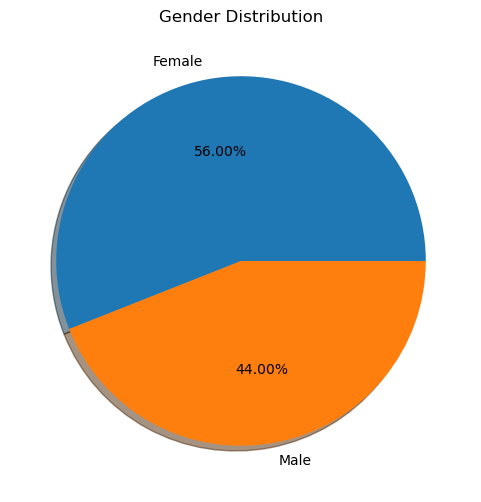

In [13]:
gender_counts = data['Gender'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%.2f%%', shadow=True)
plt.title('Gender Distribution')
plt.show()

⚙️ **Test Your Work:**

- Histograms or KDE plots successfully created for key attributes

## Task 4: Explore Relationships Between Variables
**Context:** See how features interact with one another.

**Steps:**

1. Create scatter plots (e.g.,  `Annual Income vs Spending Score`).
2. Use `sns.pairplot()` to visualize multiple feature relationships at once.


**Prompting Questions:**

- Do higher incomes always mean higher spending?
- Are there visible groups or bands forming in scatter plots?


💡 **Tip:** Scatter plots often reveal hidden clusters before you run clustering algorithms.

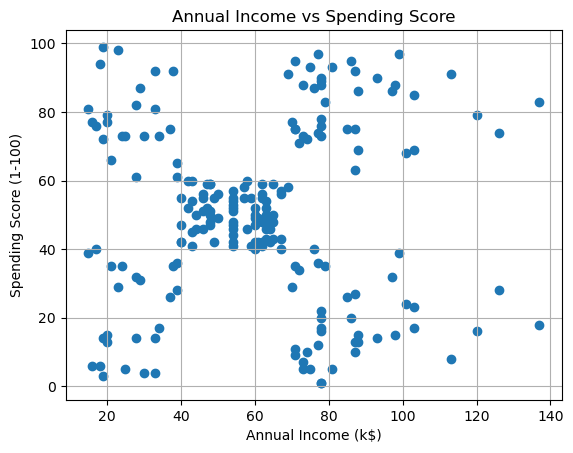

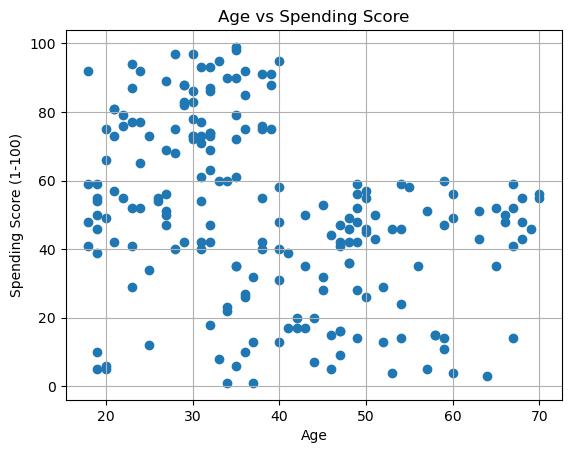

In [14]:
# Explore relationships between features with scatter plots

# Scatter plot: Income vs Spending Score
plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'])
plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.show()

# Scatter plot: Age vs Spending Score
plt.scatter(data['Age'], data['Spending Score (1-100)'])
plt.title('Age vs Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.show()

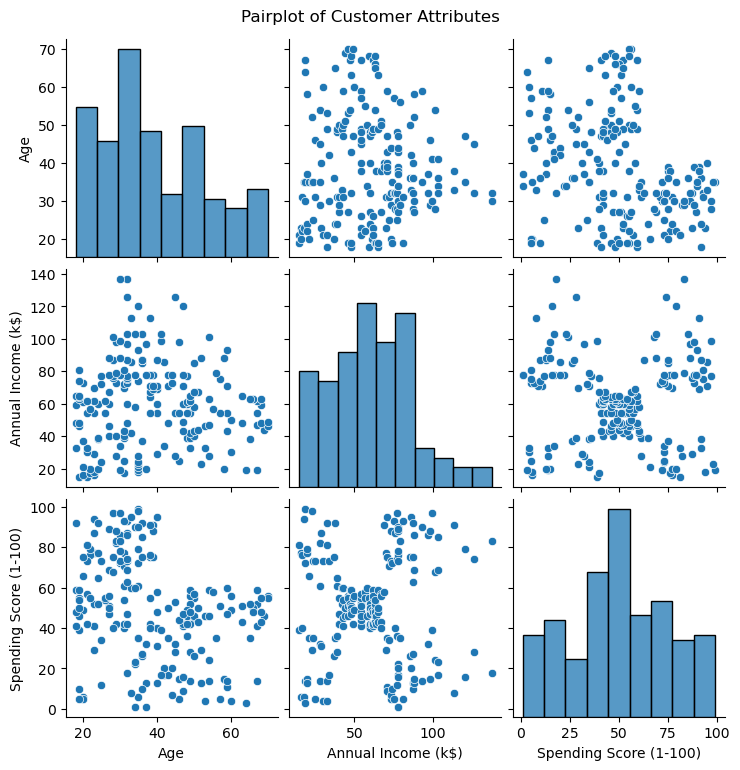

In [15]:
# Pairplot: Quick overview
sns.pairplot(data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
plt.suptitle('Pairplot of Customer Attributes', y=1.02)
plt.show()

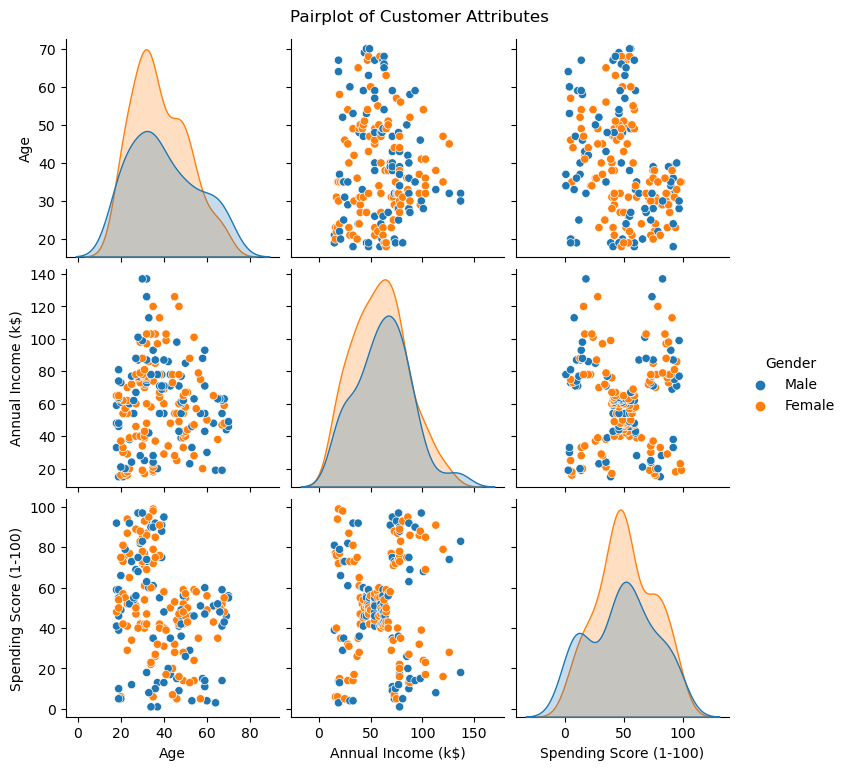

In [19]:
sns.pairplot(data=data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']], hue='Gender')
plt.suptitle('Pairplot of Customer Attributes', y=1.02)
plt.show()


⚙️ **Test Your Work:**

- Scatter plots show patterns or groupings
- Pair plots highlight correlated feature pairs


## Task 5: Analyze Outliers and Anomalies
**Context:** Outliers can dramatically affect clustering results.

**Steps:**

1. Create box plots for  `Age`,  `Annual Income`, and  `Spending Score.
2. Identify potential outliers visually.
3. Reflect: Should outliers be removed, treated, or kept?

**Prompting Questions:**

- Are outliers real customer behaviors or data errors?
- How might extreme values affect clustering?


💡 **Tip:** Only remove outliers if they represent clear data errors, not genuine rare customers.

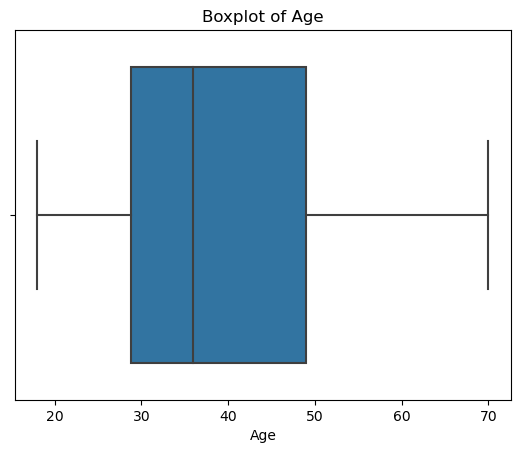

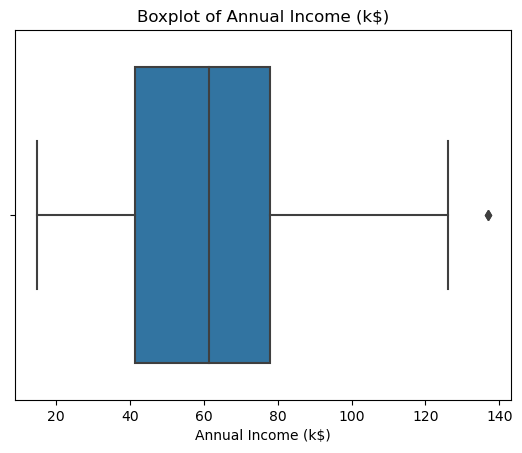

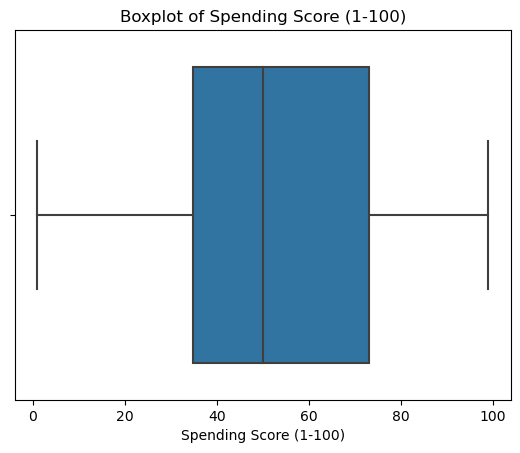

In [20]:
# Analyze outliers using boxplots

sns.boxplot(x=data['Age'])
plt.title('Boxplot of Age')
plt.show()

# Boxplot: Annual Income
sns.boxplot(x=data['Annual Income (k$)'])
plt.title('Boxplot of Annual Income (k$)')
plt.show()

# Boxplot: Spending Score
sns.boxplot(x=data['Spending Score (1-100)'])
plt.title('Boxplot of Spending Score (1-100)')
plt.show()

⚙️ **Test Your Work:**

- Boxplots clearly show distribution and potential outliers

## Task 6: Reflect on Insights Gained
**Context:** Turn your visual discoveries into clustering strategies.

**Steps:**

1. Consider how you might define clusters based on attributes (e.g., High Income/High Spending vs Low Income/Low Spending).
2. List at least 2–3 ways customer groups might be separated.

**Prompting Questions:**

- What are the clearest groups based on the plots?
- Which features seem most important for grouping customers?


💡 **Tip:** Think like a business analyst — how would a company use these clusters?


------------ **Answer** ------------

**Insights:**
- Customers seem to fall into groups based on income and spending score.
- Some customers have high income but moderate/low spending.
- Younger customers might spend more aggressively compared to older customers.
- Spending scores show potential for natural clusters (visible in scatterplots).

**Possible clusters to try:**
- High Income - High Spending
- Low Income - High Spending
- Mid Income - Mid Spending
- Older customers with different spending patterns

## ✅ Success Checklist

- Dataset loaded and basic exploration completed
- Missing values and outliers checked and addressed
- Distributions plotted and interpreted
- Relationships between key variables explored
- Outliers visualized and analyzed
- Reflection and proposed clustering ideas documented


## 🔍 Common Issues & Solutions

**Problem:** CSV file not found

**Solution:** Double-check filename and working directory
 
**Problem:** Plots not displaying

**Solution:** Ensure `plt.show()`is called after plotting
 
**Problem:** Categorical data errors in numeric columns

**Solution:** Verify dataset types and use`pd.to_numeric()` if needed

## 🔑 Key Points

- Exploratory data analysis is critical to understand and prepare for unsupervised learning
- Outliers must be carefully analyzed before clustering
- Thoughtful feature selection and insight gathering improve clustering quality


## 💻 Exemplar Solution
After completing this activity (or if you get stuck!), take a moment to review the exemplar solution. This sample solution can offer insights into different techniques and approaches.
Reflect on what you can learn from the exemplar solution to improve your coding skills.
Remember, multiple solutions can exist for some problems; the goal is to learn and grow as a programmer by exploring various approaches.
Use the exemplar solution as a learning tool to enhance your understanding and refine your approach to coding challenges.


<details>

<summary><strong>Click HERE to see an exemplar solution</strong></summary>    
    
```python
    # -------------------------------
# Task 1: Load and Explore Dataset
# -------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv('Mall_Customers.csv')

# Quick look
print(data.head())
print(data.describe())
print(data.info())

# -------------------------------
# Task 2: Preprocess the Data
# -------------------------------

# Check for missing values
print(data.isnull().sum())

# Check data types
print(data.dtypes)

# No missing values expected in this dataset
# Optionally, check for weird values or convert columns if needed

# -------------------------------
# Task 3: Visualize Basic Distributions
# -------------------------------

# Histogram: Age
plt.hist(data['Age'], bins=20, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Histogram: Annual Income
plt.hist(data['Annual Income (k$)'], bins=20, edgecolor='black')
plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')
plt.show()

# Histogram: Spending Score
plt.hist(data['Spending Score (1-100)'], bins=20, edgecolor='black')
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Frequency')
plt.show()

# -------------------------------
# Task 4: Explore Relationships Between Variables
# -------------------------------

# Scatter plot: Income vs Spending Score
plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'])
plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.show()

# Scatter plot: Age vs Spending Score
plt.scatter(data['Age'], data['Spending Score (1-100)'])
plt.title('Age vs Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.show()

# Pairplot: Quick overview
sns.pairplot(data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
plt.suptitle('Pairplot of Customer Attributes', y=1.02)
plt.show()

# -------------------------------
# Task 5: Analyze Outliers and Anomalies
# -------------------------------

# Boxplot: Age
sns.boxplot(x=data['Age'])
plt.title('Boxplot of Age')
plt.show()

# Boxplot: Annual Income
sns.boxplot(x=data['Annual Income (k$)'])
plt.title('Boxplot of Annual Income (k$)')
plt.show()

# Boxplot: Spending Score
sns.boxplot(x=data['Spending Score (1-100)'])
plt.title('Boxplot of Spending Score (1-100)')
plt.show()

# -------------------------------
# Task 6: Reflect on Insights Gained
# -------------------------------

"""
Insights:
- Customers seem to fall into groups based on income and spending score.
- Some customers have high income but moderate/low spending.
- Younger customers might spend more aggressively compared to older customers.
- Spending scores show potential for natural clusters (visible in scatterplots).
Possible clusters to try:
- High Income - High Spending
- Low Income - High Spending
- Mid Income - Mid Spending
- Older customers with different spending patterns
"""

```